In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
df = pd.read_csv('covid_19_data.csv')
df.head()

,SNo,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered
0,1,01/22/2020,Anhui,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
1,2,01/22/2020,Beijing,Mainland China,1/22/2020 17:00,14.0,0.0,0.0
2,3,01/22/2020,Chongqing,Mainland China,1/22/2020 17:00,6.0,0.0,0.0
3,4,01/22/2020,Fujian,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
4,5,01/22/2020,Gansu,Mainland China,1/22/2020 17:00,0.0,0.0,0.0


In [4]:
df['Country/Region'].value_counts()

Russia                 30251
US                     26740
Japan                  18059
Mainland China         15758
India                  13182
                       ...  
 Azerbaijan                1
North Ireland              1
Republic of Ireland        1
Cape Verde                 1
East Timor                 1
Name: Country/Region, Length: 229, dtype: int64

In [5]:
df['Province/State'].value_counts()

Unknown                         4123
Amazonas                        1109
Diamond Princess cruise ship     924
Grand Princess                   882
Punjab                           708
                                ... 
Harrison County, KY                1
Johnson County, IA                 1
Queens County, NY                  1
Unassigned Location, VT            1
Charlotte County, FL               1
Name: Province/State, Length: 737, dtype: int64

In [6]:
us = df[df['Country/Region'] == 'US']
us.head()

,SNo,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered
31,32,01/22/2020,Washington,US,1/22/2020 17:00,1.0,0.0,0.0
71,72,01/23/2020,Washington,US,1/23/20 17:00,1.0,0.0,0.0
121,122,01/24/2020,Washington,US,1/24/20 17:00,1.0,0.0,0.0
122,123,01/24/2020,Chicago,US,1/24/20 17:00,1.0,0.0,0.0
164,165,01/25/2020,Washington,US,1/25/20 17:00,1.0,0.0,0.0


In [7]:
us['Province/State'].value_counts()

Washington               456
Illinois                 453
California               452
Arizona                  452
South Carolina           446
                        ... 
Collin County, TX          1
Jefferson County, KY       1
Jefferson Parish, LA       1
Shasta County, CA          1
Santa Cruz County, CA      1
Name: Province/State, Length: 199, dtype: int64

In [8]:
wash = us[us['Province/State'] == 'Washington']
wash.head()

,SNo,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered
31,32,01/22/2020,Washington,US,1/22/2020 17:00,1.0,0.0,0.0
71,72,01/23/2020,Washington,US,1/23/20 17:00,1.0,0.0,0.0
121,122,01/24/2020,Washington,US,1/24/20 17:00,1.0,0.0,0.0
164,165,01/25/2020,Washington,US,1/25/20 17:00,1.0,0.0,0.0
210,211,01/26/2020,Washington,US,1/26/20 16:00,1.0,0.0,0.0


In [9]:
wash.describe()

,SNo,Confirmed,Deaths,Recovered
count,456.000000,456.000000,456.000000,456.000000
mean,137501.447368,162655.589912,2680.828947,0.017544
std,94006.222615,145389.224551,1763.391478,0.131430
min,32.000000,1.000000,0.000000,0.000000
25%,48391.750000,29264.000000,1251.750000,0.000000
50%,132971.000000,97589.000000,2191.500000,0.000000
75%,219387.250000,318251.250000,4424.250000,0.000000
max,306406.000000,435849.000000,5765.000000,1.000000


In [10]:
wash.isnull().sum()

SNo                0
ObservationDate    0
Province/State     0
Country/Region     0
Last Update        0
Confirmed          0
Deaths             0
Recovered          0
dtype: int64

In [11]:
wash = wash.drop(['SNo','Province/State','Country/Region','Last Update'],axis=1)

In [12]:
wash.head()

,ObservationDate,Confirmed,Deaths,Recovered
31,01/22/2020,1.0,0.0,0.0
71,01/23/2020,1.0,0.0,0.0
121,01/24/2020,1.0,0.0,0.0
164,01/25/2020,1.0,0.0,0.0
210,01/26/2020,1.0,0.0,0.0


In [13]:
wash.rename(columns={'ObservationDate': 'Date'}, inplace=True)

In [14]:
wash['Date'] = pd.to_datetime(wash['Date'])

In [15]:
wash.set_index('Date', inplace=True)

In [16]:
wash.head()

,Confirmed,Deaths,Recovered
Date,,,
2020-01-22,1.0,0.0,0.0
2020-01-23,1.0,0.0,0.0
2020-01-24,1.0,0.0,0.0
2020-01-25,1.0,0.0,0.0
2020-01-26,1.0,0.0,0.0


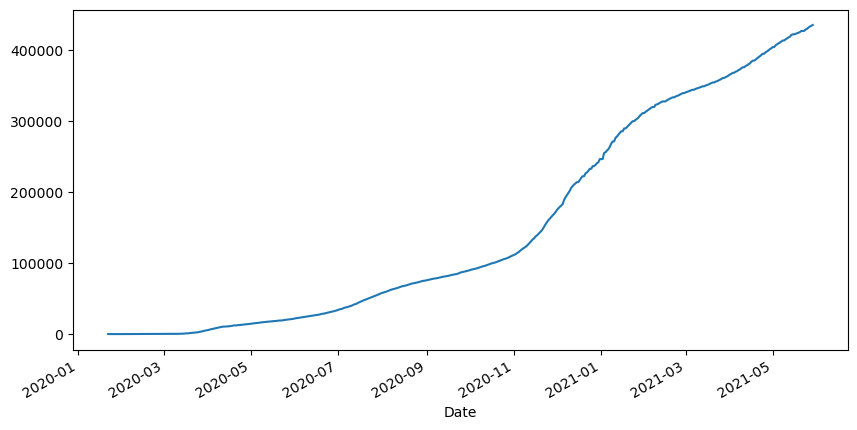

In [17]:
wash['Confirmed'].plot(figsize=(10,5));

In [18]:
import pmdarima as pmd

In [19]:
Ntest = 30
train = wash['Confirmed'].iloc[:-Ntest]
test = wash['Confirmed'].iloc[-Ntest:]

In [38]:
#model = pmd.auto_arima(train, error_action='ignore', trace=True, supress_warning=True, seasonal=False)
model = pmd.auto_arima(train, error_action='ignore', trace=True, supress_warning=True, max_p=12, max_q=2, max_order=14,
                     stepwise=True,
                     seasonal=False)

Performing stepwise search to minimize aic
 ARIMA(2,2,2)(0,0,0)[0] intercept   : AIC=6740.294, Time=0.62 sec
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=7100.409, Time=0.02 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=6920.322, Time=0.05 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=6775.664, Time=0.31 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=7098.419, Time=0.02 sec
 ARIMA(1,2,2)(0,0,0)[0] intercept   : AIC=6739.169, Time=0.67 sec
 ARIMA(0,2,2)(0,0,0)[0] intercept   : AIC=6737.976, Time=0.41 sec
 ARIMA(1,2,1)(0,0,0)[0] intercept   : AIC=6747.693, Time=0.33 sec
 ARIMA(0,2,2)(0,0,0)[0]             : AIC=6736.349, Time=0.17 sec
 ARIMA(0,2,1)(0,0,0)[0]             : AIC=6774.183, Time=0.10 sec
 ARIMA(1,2,2)(0,0,0)[0]             : AIC=6737.511, Time=0.26 sec
 ARIMA(1,2,1)(0,0,0)[0]             : AIC=6746.167, Time=0.16 sec

Best model:  ARIMA(0,2,2)(0,0,0)[0]          
Total fit time: 3.117 seconds


In [39]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  426
Model:               SARIMAX(0, 2, 2)   Log Likelihood               -3365.175
Date:                Wed, 11 Oct 2023   AIC                           6736.349
Time:                        20:53:41   BIC                           6748.498
Sample:                             0   HQIC                          6741.149
                                - 426                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -1.1628      0.024    -48.233      0.000      -1.210      -1.116
ma.L2          0.3315      0.025     13.040      0.000       0.282       0.381
sigma2      4.576e+05   1.11e+04     41.174      0.000    4.36e+05    4.79e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.09   Jarque-Bera (JB):              8793.41
Prob(Q):                              0.77   Prob(JB):                         0.00
Heteroskedasticity (H):              44.41   Skew:                             1.45
Prob(H) (two-sided):                  0.00   Kurtosis:                        25.12
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [40]:
test_pred, confint = model.predict(n_periods=Ntest, return_conf_int=True)

C:\Users\pc\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


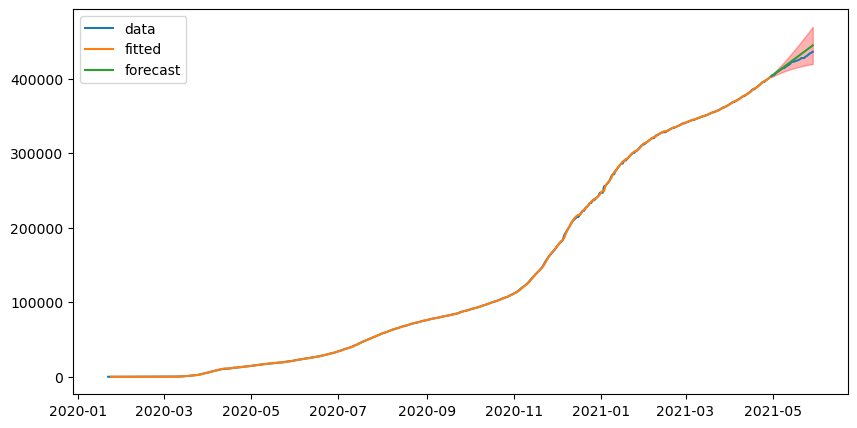

In [41]:
train_pred = model.predict_in_sample(start=2, end=-1)

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(wash.index, wash['Confirmed'], label='data')
ax.plot(train.index[2:], train_pred, label='fitted')
ax.plot(test.index, test_pred, label='forecast')
ax.fill_between(test.index, \
               confint[:,0], confint[:,1], \
               color='red', alpha=0.3)
ax.legend();

C:\Users\pc\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


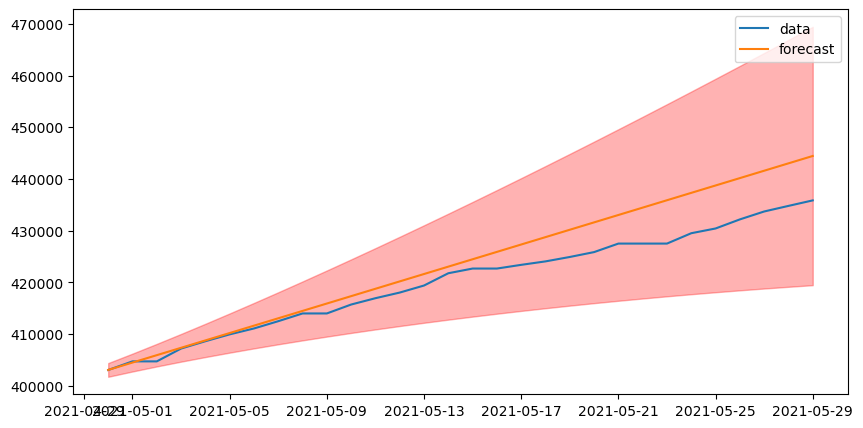

In [42]:
test_pred, confint = model.predict(n_periods=Ntest, return_conf_int=True)

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(test.index, test, label='data')
ax.plot(test.index, test_pred, label='forecast')
ax.fill_between(test.index, \
               confint[:,0], confint[:,1], \
               color='red', alpha=0.3)
ax.legend();

In [24]:
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot

In [25]:
df = wash.drop(['Deaths','Recovered'],axis=1)
df.head()

,Confirmed
Date,
2020-01-22,1.0
2020-01-23,1.0
2020-01-24,1.0
2020-01-25,1.0
2020-01-26,1.0


In [26]:
df.columns = ['y']

In [27]:
df['ds'] = df.index

In [28]:
df.head()

,y,ds
Date,,
2020-01-22,1.0,2020-01-22
2020-01-23,1.0,2020-01-23
2020-01-24,1.0,2020-01-24
2020-01-25,1.0,2020-01-25
2020-01-26,1.0,2020-01-26


In [29]:
m = Prophet()
m.fit(df)

20:50:14 - cmdstanpy - INFO - Chain [1] start processing
20:50:14 - cmdstanpy - INFO - Chain [1] done processing


In [30]:
future = m.make_future_dataframe(periods=30, freq='D')
forecast = m.predict(future)

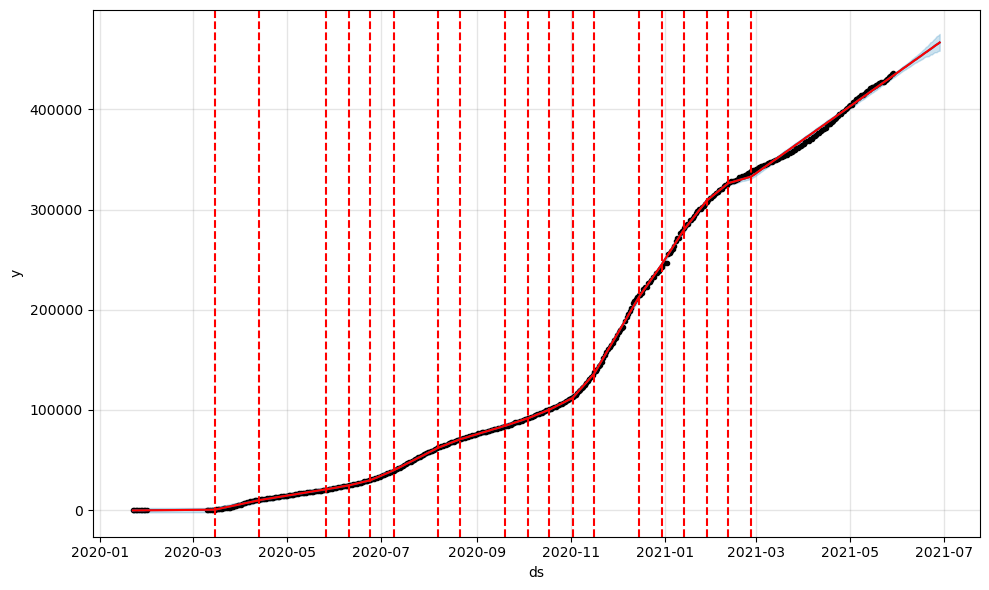

In [31]:
fig = m.plot(forecast);
a = add_changepoints_to_plot(fig.gca(), m, forecast)